# Superstore Profit prediction

## TABLE OF CONTENT

### 1. Import Libraries

In [57]:
#import Libraries

# standard library 
import os
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd


# visualization
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Scikit-learn - preprocessing & modelling
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Notebook display helpers
from IPython.display import display

# Reproducibility seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

print("All libraries loaded successfully.")

All libraries loaded successfully.


### 2. Load the Dataset 

In [58]:

DATA_PATH = "../data/Superstore.csv"

# Some exports of the Superstore dataset  use latin-1 encoding
df_raw = pd.read_csv(DATA_PATH,  encoding="latin-1") #This is the original dataset when we want to access it

# the data set used for analysis
df = df_raw.copy()


print(f"Dataset shape : {df.shape[0]:,} rows x {df.shape[1]} columns\n")
print("---First 5 rows---")
display(df.head())

print("---Last 5 rows---")
display(df.tail())


Dataset shape : 9,994 rows x 21 columns

---First 5 rows---


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


---Last 5 rows---


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


### 3. Initial inspection

In [59]:
# Data types and non-null counts
print("--- .info() ---")
df.info()

print("\n ----Descriptive statistics (numeric)----")
display(df.describe().T.round(2))

--- .info() ---


<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

,count,mean,std,min,25%,50%,75%,max
Row ID,9994.0,4997.50,2885.16,1.00,2499.25,4997.50,7495.75,9994.00
Postal Code,9994.0,55190.38,32063.69,1040.00,23223.00,56430.50,90008.00,99301.00
Sales,9994.0,229.86,623.25,0.44,17.28,54.49,209.94,22638.48
Quantity,9994.0,3.79,2.23,1.00,2.00,3.00,5.00,14.00
Discount,9994.0,0.16,0.21,0.00,0.00,0.20,0.20,0.80
Profit,9994.0,28.66,234.26,-6599.98,1.73,8.67,29.36,8399.98


In [60]:
# missing values
missing = df.isnull().sum()
missing_pct =(missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
}).query("`Missing Count` > 0")

if missing_report.empty:
    print("No missing values found.")
else:
    print("Missing Values detected:")
    display(missing_report)

No missing values found.


In [61]:
# duplicates
n_dupes = df.duplicated().sum()
if n_dupes > 0:
    print(f"Found {n_dupes} duplicate rows.")
else:
    print("No duplicate rows found.")

No duplicate rows found.


In [62]:
# Data Types Overview
print("Column dtypes:\n")
print(df.dtypes.to_string())

Column dtypes:

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64


### 4. Exploratory Data Analysis(EDA) 
- **GOAL:** Understand distributions, relationships and trends

#### 4.1 Univariate Distributions

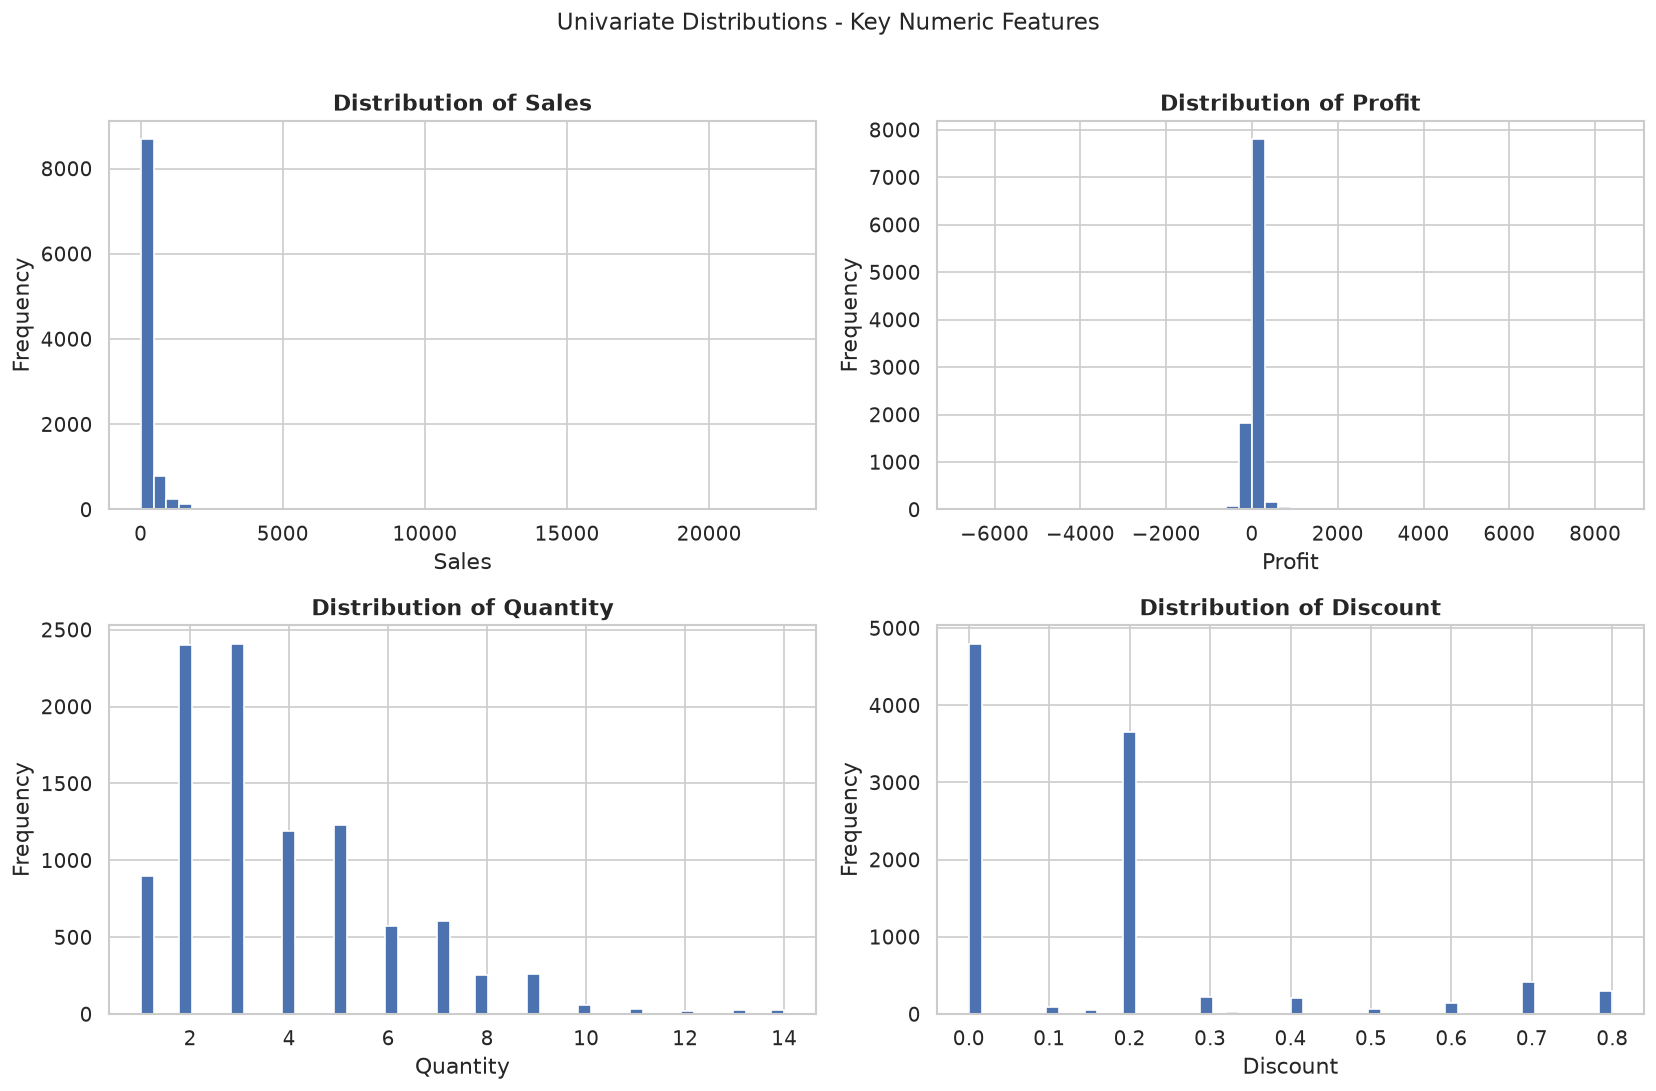

In [63]:
# Histogram
numeric_cols = ["Sales", "Profit", "Quantity", "Discount"]
fig, axes = plt.subplots(2, 2, figsize=(14,9))

for ax, col in zip(axes.flatten(), numeric_cols):
    df[col].hist(bins=50, ax=ax, color="#4c72b0", edgecolor="white")
    ax.set_title(f"Distribution of {col}", fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.suptitle("Univariate Distributions - Key Numeric Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../reports/fig01_univariate_histogramss.png", bbox_inches="tight")
plt.show()

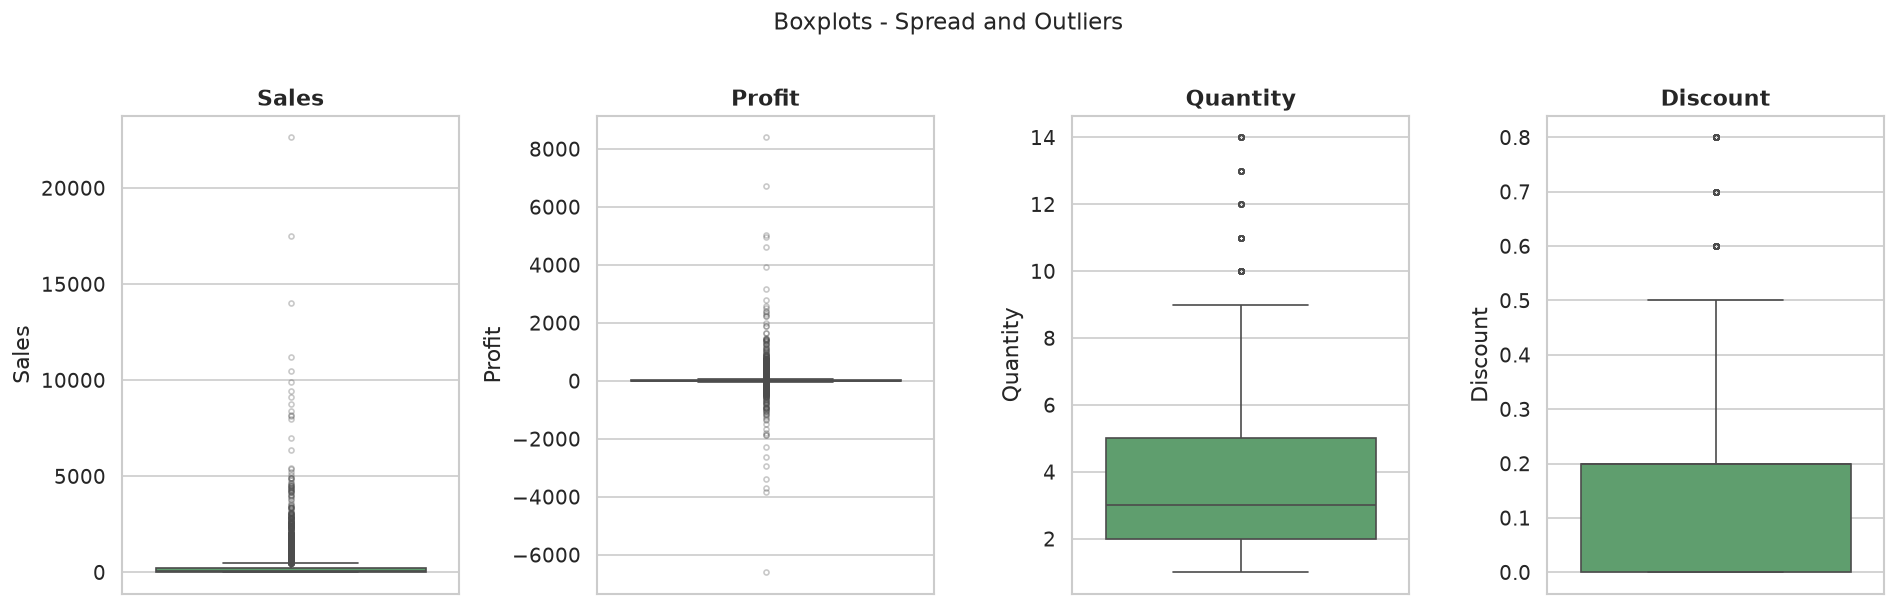

In [64]:
# Boxplots (outlier inspection)

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="#55a868", flierprops=dict(marker=".", alpha=0.3))
    ax.set_title(col, fontweight="bold")
    
plt.suptitle("Boxplots - Spread and Outliers", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../reports/fig02_boxplots.png", bbox_inches="tight")
plt.show()

#### 4.2 Bivariate Analysis

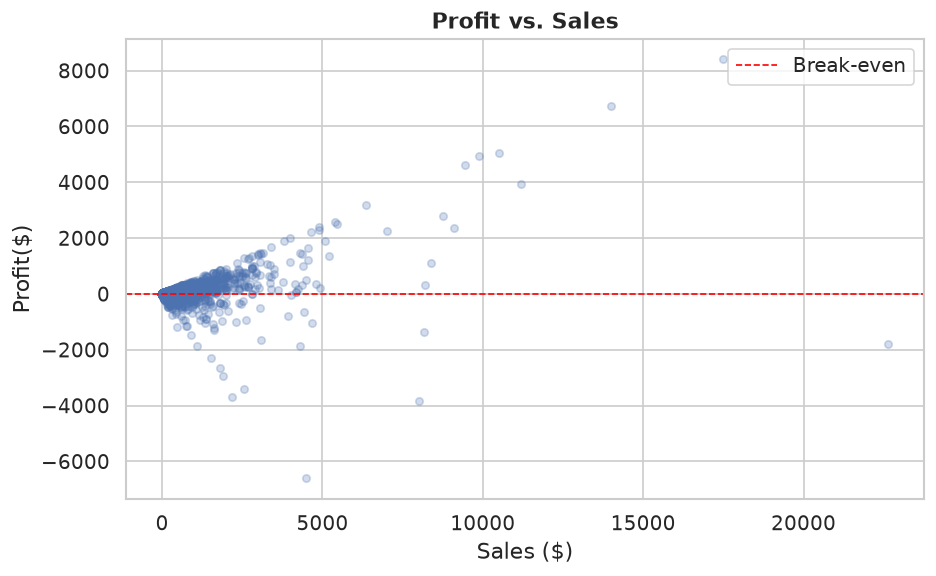

In [65]:
# Profit vs Sales scatter
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["Sales"], df["Profit"], alpha=0.25, s=20, color="#4c72b0")
ax.axhline(0, color="red", linestyle="--", linewidth=1, label="Break-even")
ax.set_xlabel("Sales ($)")
ax.set_ylabel("Profit($)")
ax.set_title("Profit vs. Sales", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/fig03_profit_vs_sales.png", bbox_inches="tight")
plt.show()

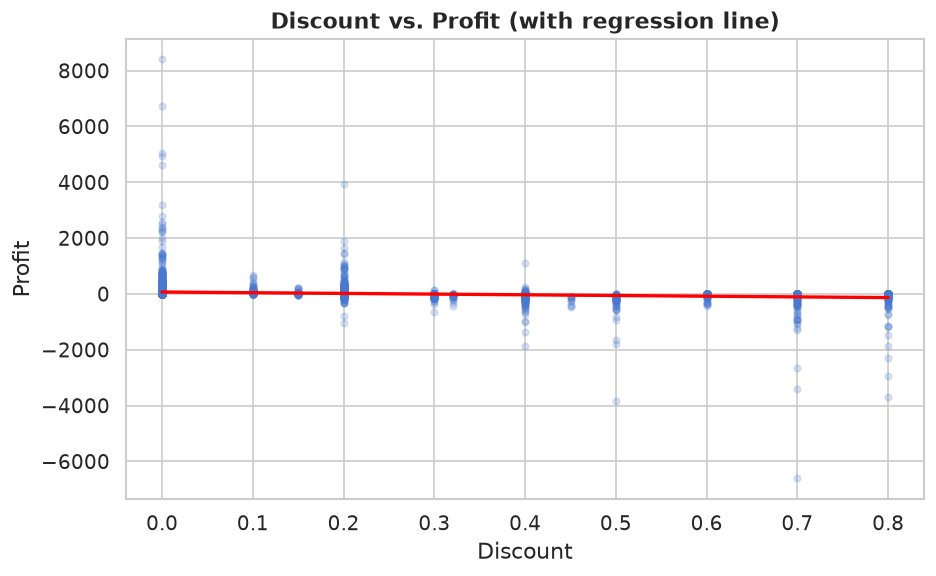

In [66]:
# Discount vs Profit
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(
    data=df,
    x="Discount",
    y="Profit",
    ax=ax,
    scatter_kws={"alpha": 0.2, "s": 15},
    line_kws={"color": "red", "linewidth": 2}
)
ax.set_title("Discount vs. Profit (with regression line)", fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/fig04_discount_vs_profit.png", bbox_inches="tight")
plt.show()


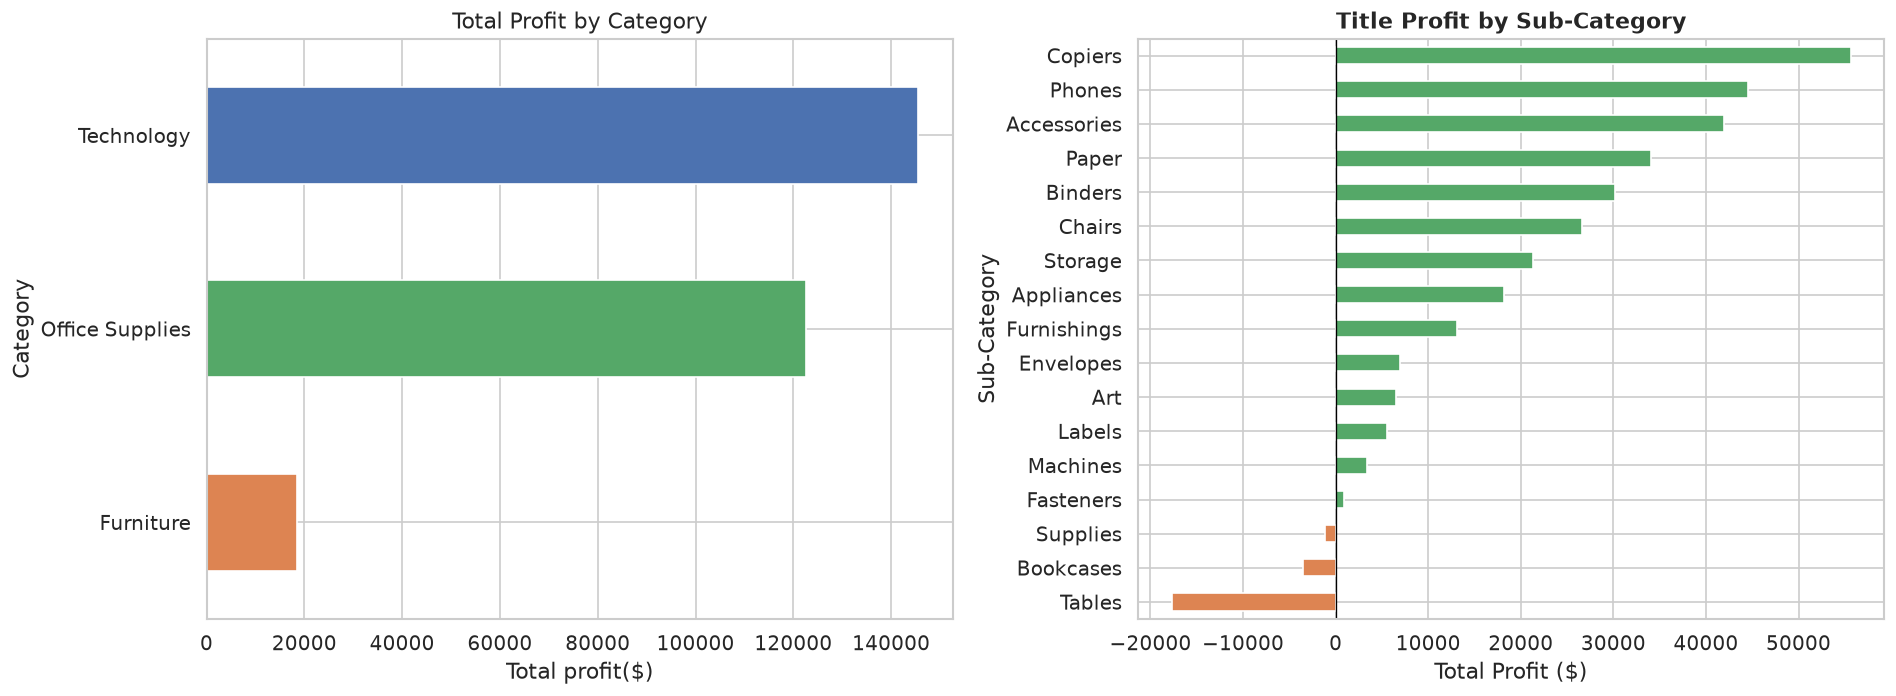

In [67]:
# profit by category and subcategory
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# Category
cat_profit = df.groupby("Category")["Profit"].sum().sort_values()
cat_profit.plot(kind="barh", ax=axes[0], color=["#dd8452", "#55a868", "#4c72b0"])
axes[0].set_title("Total Profit by Category")
axes[0].set_xlabel("Total profit($)")

# sub-category
subcat_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values()
colors = ["#dd8452" if v < 0 else "#55a868" for v in subcat_profit]
subcat_profit.plot(kind="barh", ax=axes[1], color=colors)
axes[1].set_title("Title Profit by Sub-Category", fontweight="bold")
axes[1].set_xlabel("Total Profit ($)")
axes[1].axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.savefig("../reports/fig05_profit_by_category.png", bbox_inches="tight")
plt.show()

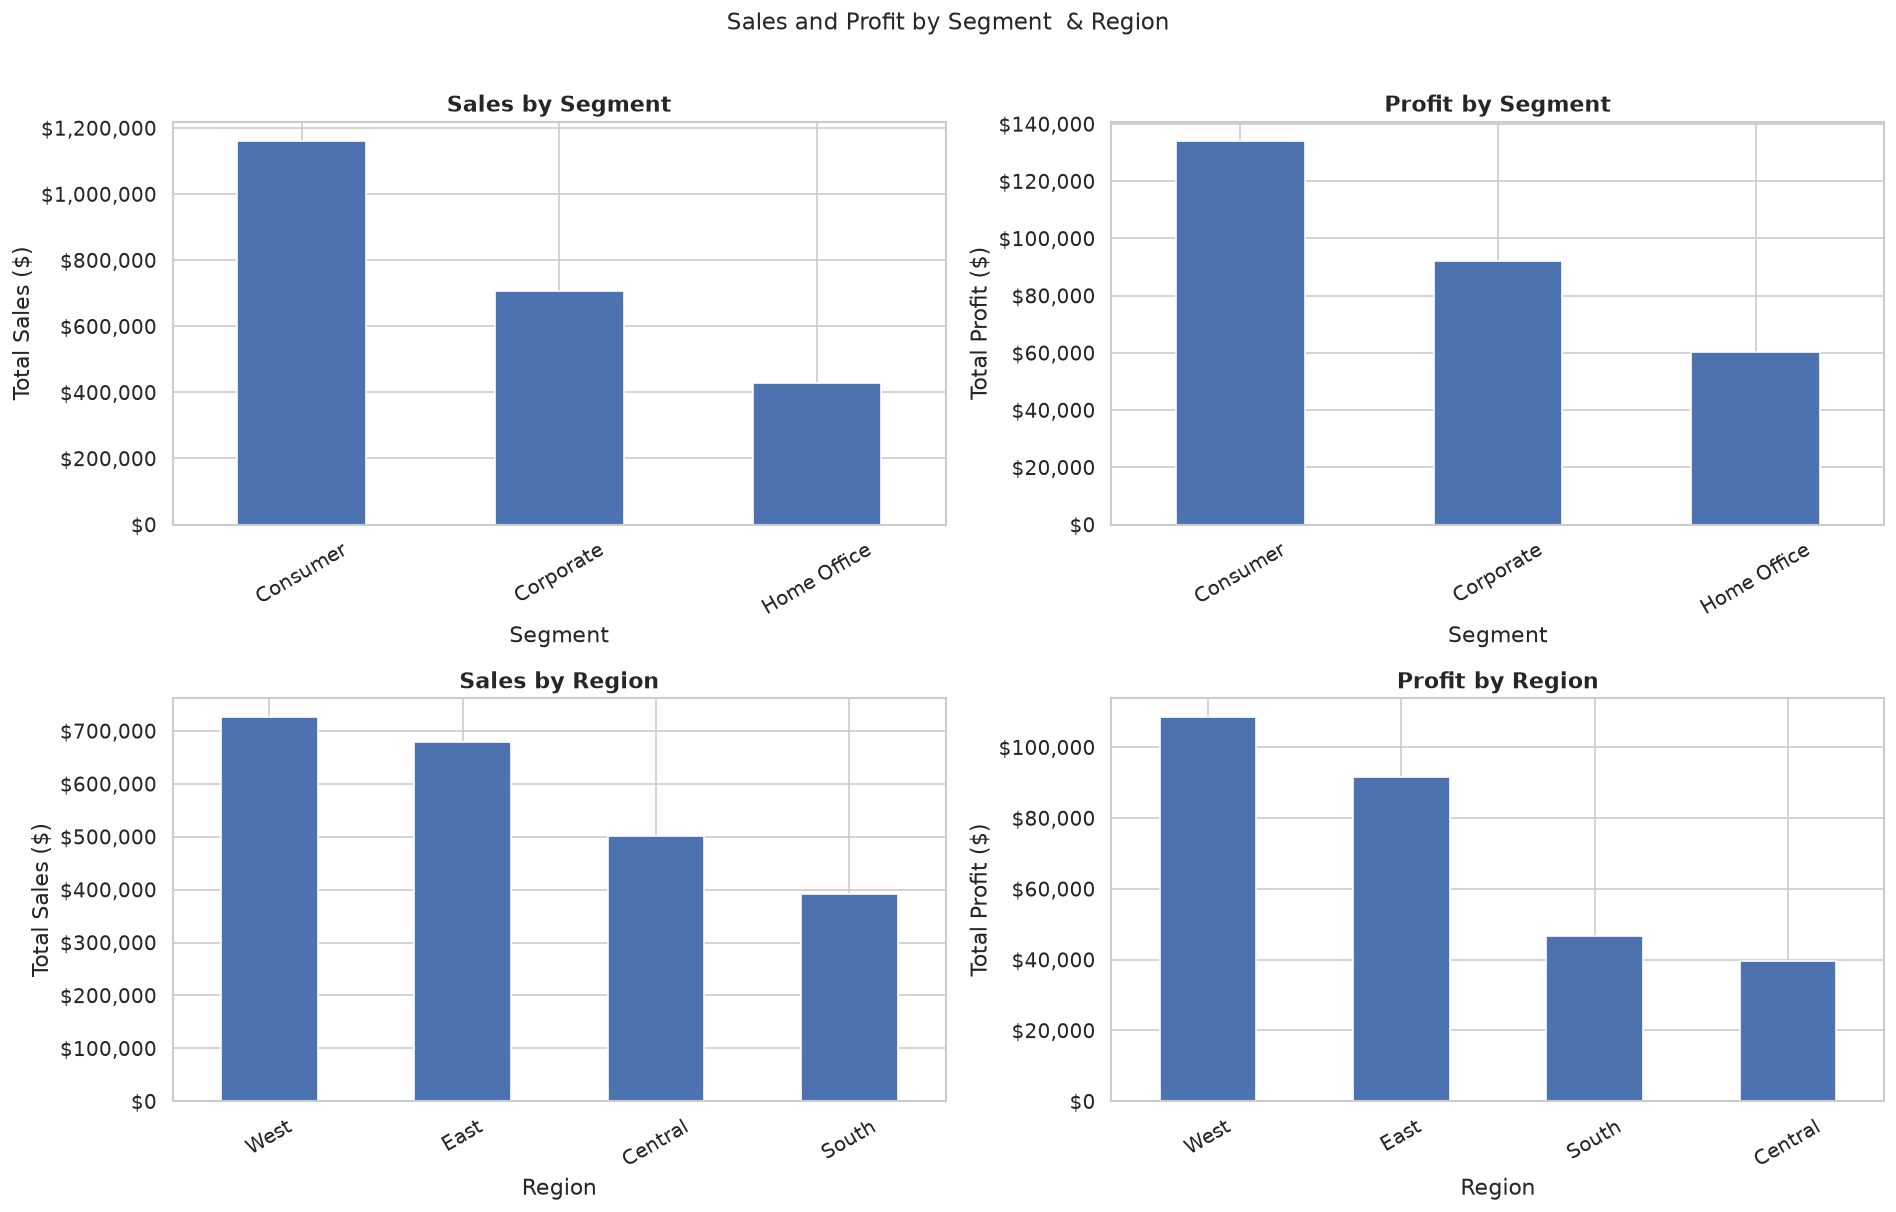

In [68]:
# Sales by profit by segment and Region
fig, axes = plt.subplots(2, 2, figsize=(16,10))

for i, (col, metric) in enumerate([
    ("Segment", "Sales"), ("Segment", "Profit"),
    ("Region", "Sales"), ("Region", "Profit")
]):
    ax = axes[i // 2][i % 2]
    grouped = df.groupby(col)[metric].sum().sort_values(ascending=False)
    grouped.plot(kind="bar", ax=ax, color="#4c72b0", edgecolor="white", rot=30)
    ax.set_title(f"{metric} by {col}", fontweight="bold")
    ax.set_ylabel(f"Total {metric} ($)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    
plt.suptitle("Sales and Profit by Segment  & Region", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../reports/fig06_sales_profit_segment_region.png", bbox_inches="tight")
plt.show()

#### 4.3 Time-Series Trends

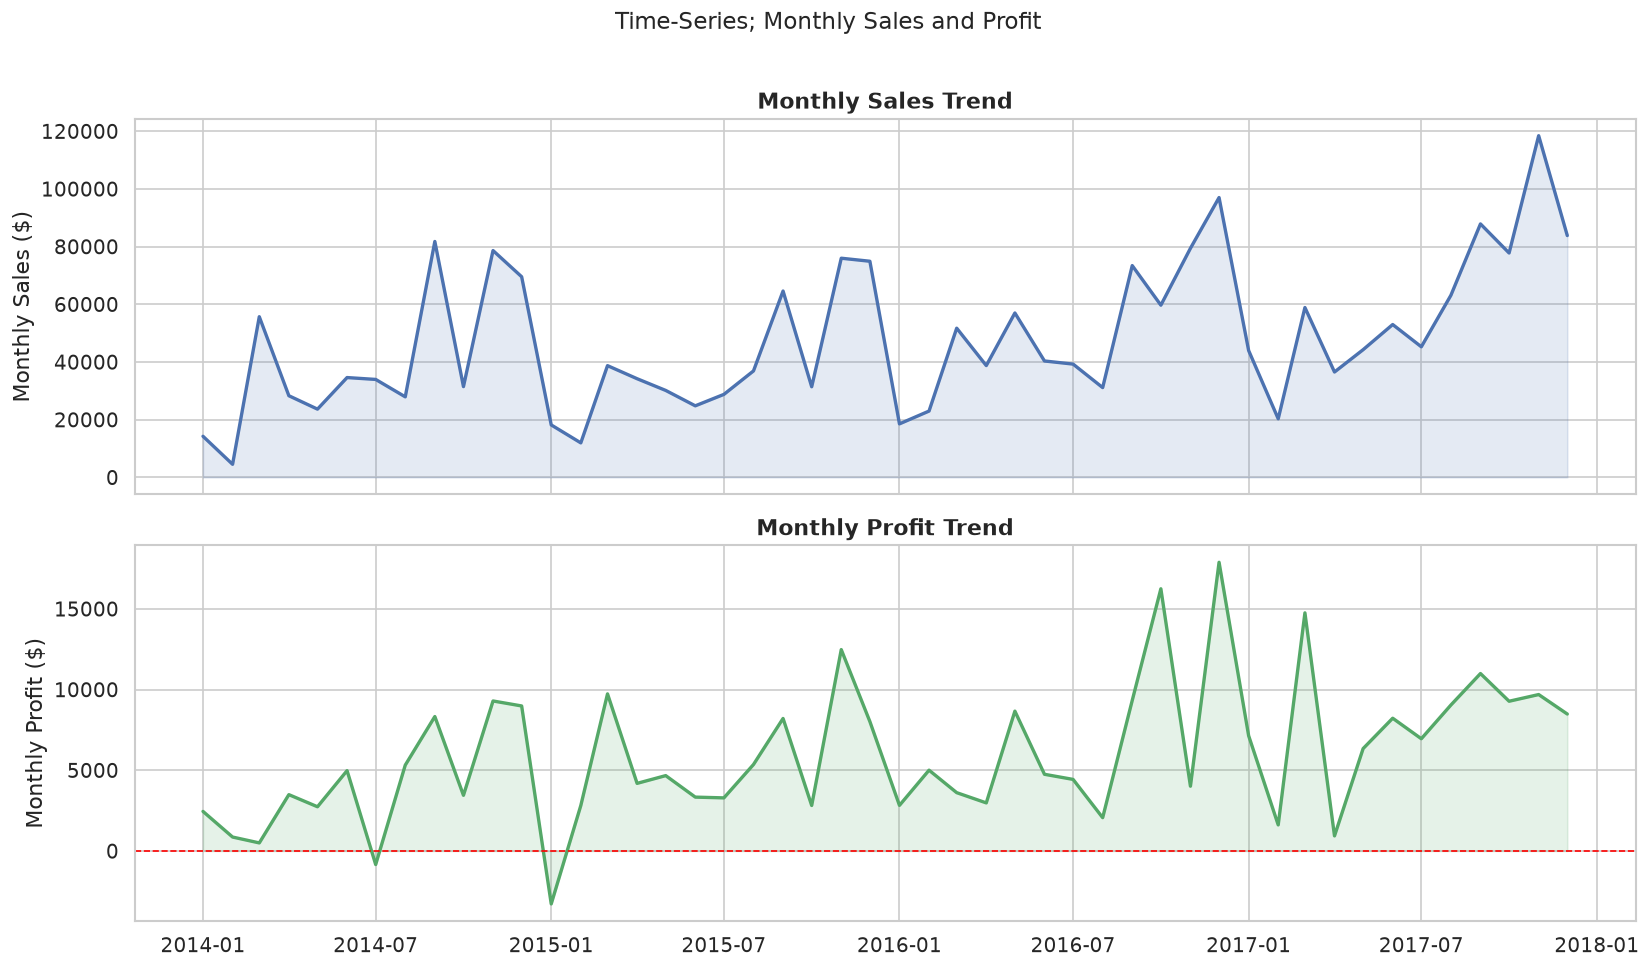

In [69]:
# monthly sales and Profit overtime

# parse date temporalily for EDA (full parse happens in phase 3)
df_ts = df.copy()
df_ts["Order Date"] = pd.to_datetime(df_ts["Order Date"])
df_ts["YearMonth"] = df_ts["Order Date"].dt.to_period("M")

monthly = df_ts.groupby("YearMonth")[["Sales","Profit"]].sum()
monthly.index = monthly.index.to_timestamp()  # convert period - datetime for plotting

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14,8), sharex=True)

ax1.plot(monthly.index, monthly["Sales"], color="#4c72b0", linewidth=2)
ax1.fill_between(monthly.index, monthly["Sales"], alpha=0.15, color="#4c72b0")
ax1.set_ylabel("Monthly Sales ($)")
ax1.set_title("Monthly Sales Trend", fontweight="bold")

ax2.plot(monthly.index, monthly["Profit"], color="#55a868", linewidth=2)
ax2.fill_between(monthly.index, monthly["Profit"], alpha=0.15, color="#55a868")
ax2.axhline(0, color="red", linestyle="--", linewidth=1)
ax2.set_ylabel("Monthly Profit ($)")
ax2.set_title("Monthly Profit Trend", fontweight="bold")

plt.suptitle("Time-Series; Monthly Sales and Profit", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../reports/fig07_monthly_trends.png", bbox_inches="tight")
plt.show()

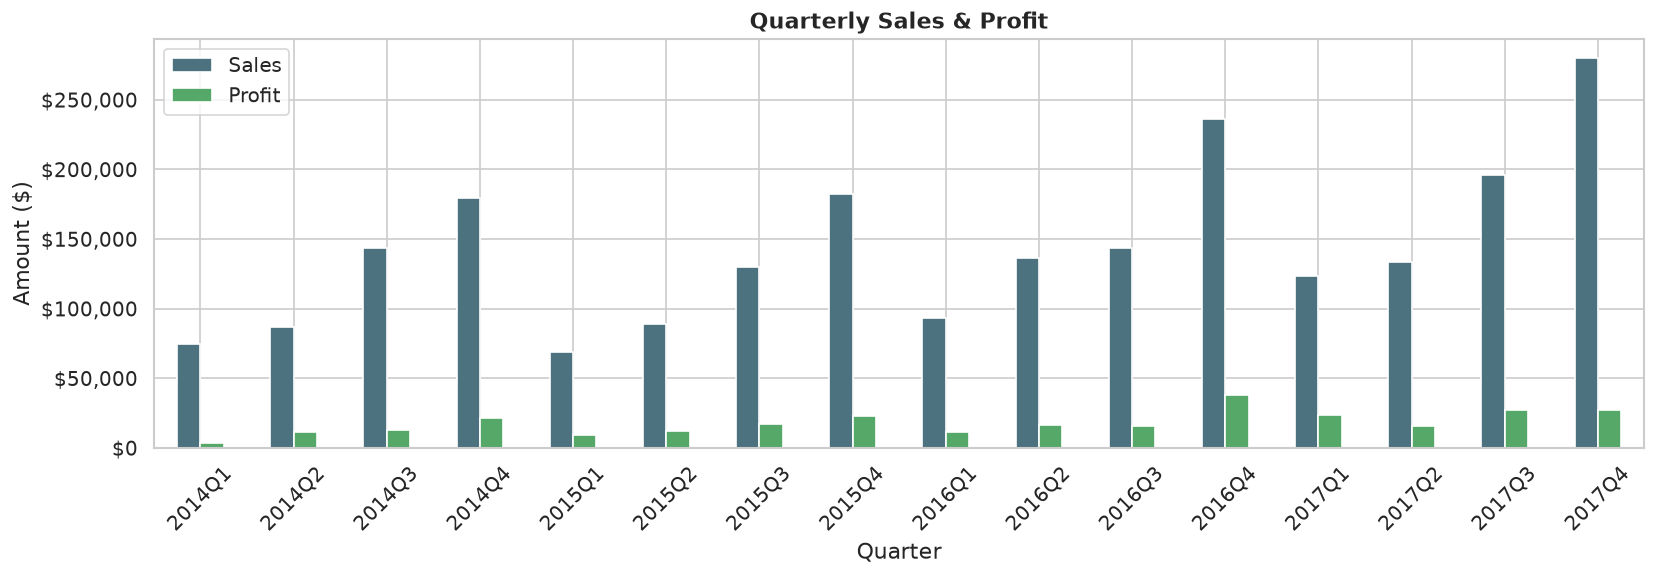

In [70]:
# Quartertly Aggregation
df_ts["Quarter"] = df_ts["Order Date"].dt.to_period("Q")
quarterly = df_ts.groupby("Quarter")[["Sales", "Profit"]].sum()
quarterly.index = quarterly.index.astype(str)

ax = quarterly.plot(kind="bar",figsize=(14,5), color=["#4c7280", "#55a868"], edgecolor="white", rot=45)
ax.set_title ("Quarterly Sales & Profit", fontweight="bold")
ax.set_ylabel("Amount ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("../reports/fig08_quarterly_tends.png", bbox_inches="tight")
plt.show()

#### 4.4 Correlation Heatmap

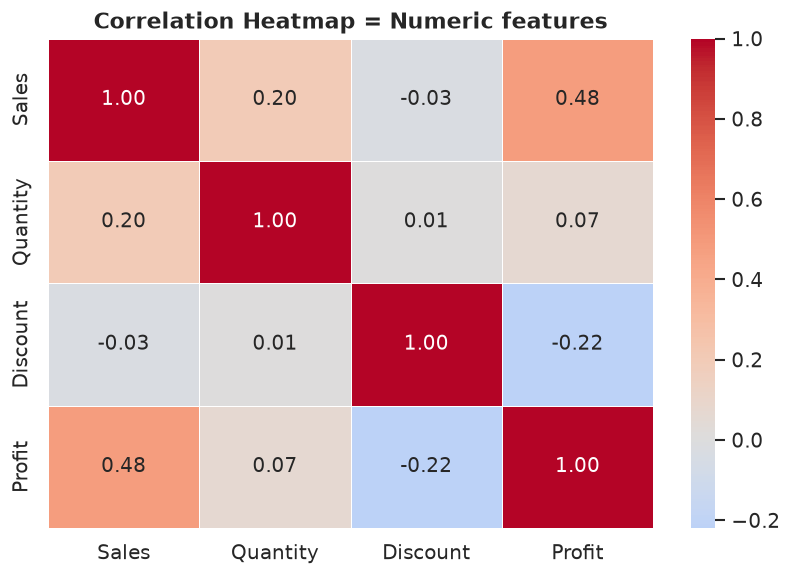

In [71]:
numeric_df = df [["Sales", "Quantity", "Discount", "Profit"]].copy()
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(7,5)) 

sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5, ax=ax, annot_kws={"size":12}
)
ax.set_title("Correlation Heatmap = Numeric features", fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/fig09_correlation_heatmap.png", bbox_inches="tight")
plt.show()

### 5. Data Cleaning & Feature Engineering

#### 5.1 Handling Missing Values and Outliers

In [72]:
# reinspect missing values
print(f"Missing Values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

# if any numeric column has missing values, fill with the column median
for col in ["Sales", "Profit", "Quantity", "Discount"]:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())
        print(f" Filled {col} missing values with median")

Missing Values:
Series([], dtype: int64)


In [73]:
# cap outliers
def cap_outliers(series, lower_pct=0.01, upper_pct=0.99):
    """Cap values at the given percentile bounds."""
    low = series.quantile(lower_pct)
    high= series.quantile(upper_pct)
    return series.clip(lower=low, upper=high)

for col in ["Sales", "Profit"]:
    before_std = df[col].std()
    df[col] = cap_outliers(df[col])
    after_std  = df[col].std()
    print(f"{col}: std {before_std:.2f} - {after_std:.2f} after capping")

Sales: std 623.25 - 394.80 after capping
Profit: std 234.26 - 97.56 after capping


#### 5.2 Parse Date and Extract Time Features

In [74]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

#core date features
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Quarter"] = df["Order Date"].dt.quarter
df["Order DayOfWeek"] = df["Order Date"].dt.dayofweek

# Shipping duration in calendar days
df["Shipping Duration"] = (df["Ship Date"] - df["Order Date"]).dt.days

print("Date features created:")
display(df[["Order Date", "Ship Date", "Order Year", "Order Month", "Order Quarter", "Order DayOfWeek", "Shipping Duration"]].head())

Date features created:


,Order Date,Ship Date,Order Year,Order Month,Order Quarter,Order DayOfWeek,Shipping Duration
0,2016-11-08,2016-11-11,2016,11,4,1,3
1,2016-11-08,2016-11-11,2016,11,4,1,3
2,2016-06-12,2016-06-16,2016,6,2,6,4
3,2015-10-11,2015-10-18,2015,10,4,6,7
4,2015-10-11,2015-10-18,2015,10,4,6,7


#### 5.3 Create new features

In [75]:
# Discount Bin
def discount_bin(d):
    if d == 0:
        return "None"
    elif d <= 0.20:
        return "Low"
    elif d<= 0.40:
        return "Medium"
    else:
        return "High" 

df["Discount Bin"] = df["Discount"].apply(discount_bin)
print(df["Discount Bin"].value_counts())

Discount Bin
None      4798
Low       3803
High       933
Medium     460
Name: count, dtype: int64


#### 5.4 Encode Categorical Variables

In [76]:
# columns to one-hot encode (low to medium cardanility)
ohe_cols = ["Ship Mode", "Segment", "Region", "Category", "Discount Bin"]

# High-cardinality columns we will DROP before modelling (not encode)
drop_cols= ["Row ID", "Order ID", "Customer ID", "Customer Name", "Product ID", "Product Name","Order Date","Ship Date", "City", 
            "State", "Postal Code", "Country", "Sub-Category",]

df_model  = df.drop(columns=drop_cols, errors="ignore")

# One_hot encode
df_model = pd.get_dummies(df_model, columns=ohe_cols, drop_first=True)

print(f"Model-ready dataframe shape: {df_model.shape}")
print(f"\nColumns:\n{list(df_model.columns)}")

Model-ready dataframe shape: (9994, 22)

Columns:
['Sales', 'Quantity', 'Discount', 'Profit', 'Order Year', 'Order Month', 'Order Quarter', 'Order DayOfWeek', 'Shipping Duration', 'Ship Mode_Same Day', 'Ship Mode_Second Class', 'Ship Mode_Standard Class', 'Segment_Corporate', 'Segment_Home Office', 'Region_East', 'Region_South', 'Region_West', 'Category_Office Supplies', 'Category_Technology', 'Discount Bin_Low', 'Discount Bin_Medium', 'Discount Bin_None']


In [77]:
# check before modelling
print("Any remaining nulls?\n",df_model.isnull().sum())
print("DTypes:\n", df_model.dtypes.value_counts())
display(df_model.head(3))

Any remaining nulls?
 Sales                       0
Quantity                    0
Discount                    0
Profit                      0
Order Year                  0
Order Month                 0
Order Quarter               0
Order DayOfWeek             0
Shipping Duration           0
Ship Mode_Same Day          0
Ship Mode_Second Class      0
Ship Mode_Standard Class    0
Segment_Corporate           0
Segment_Home Office         0
Region_East                 0
Region_South                0
Region_West                 0
Category_Office Supplies    0
Category_Technology         0
Discount Bin_Low            0
Discount Bin_Medium         0
Discount Bin_None           0
dtype: int64
DTypes:
 bool       13
int32       4
float64     3
int64       2
Name: count, dtype: int64


,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Quarter,Order DayOfWeek,Shipping Duration,Ship Mode_Same Day,...,Segment_Corporate,Segment_Home Office,Region_East,Region_South,Region_West,Category_Office Supplies,Category_Technology,Discount Bin_Low,Discount Bin_Medium,Discount Bin_None
0,261.96,2,0.0,41.9136,2016,11,4,1,3,False,...,False,False,False,True,False,False,False,False,False,True
1,731.94,3,0.0,219.5820,2016,11,4,1,3,False,...,False,False,False,True,False,False,False,False,False,True
2,14.62,2,0.0,6.8714,2016,6,2,6,4,False,...,True,False,False,False,True,True,False,False,False,True


### 6. Predictive modeling


#### 6.1 Define Features and Target

In [78]:
TARGET = "Profit"
FEATURES = [c for c in df_model.columns if c != TARGET]

X = df_model[FEATURES]
y = df_model[TARGET]

print(f"Feature matrix x: {X.shape}")
print(f"Target vector y: {y.shape}")

Feature matrix x: (9994, 21)
Target vector y: (9994,)


#### 6.2  Train\Test Split

In [85]:
# 80/20 stratified split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print(f"Training set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")

Training set : 7,995 rows
Test set     : 1,999 rows


#### 6.3 Evaluation Helper

In [ ]:
# Reusable metric function

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):  #
    """Fit model, print metrics, return dict of results."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae = mean_absolute_error(y_te, y_pred)
    r2 = r2_score(y_te, y_pred)
    
    print(f"\n{'-'*40}")
    print(f" {name}")
    print(f" RMSE : {rmse:>10.4f}")
    print(f" MAE  : {mae:>10.4f}")
    print(f" R2   : {r2:>10.4f}")
    
    return {"Model": name, "RMSE": round(rmse, 4), "MAE": round(mae, 4), "R2": round(r2, 4)} 

#### 6.4 Baseline -- Linear Regression

In [88]:
lr = LinearRegression()
lr_results = evaluate_model(
    "LinearRegression", lr, X_train, y_train, X_test, y_test
)


----------------------------------------
 LinearRegression
 RMSE :    79.0926
 MAE  :    38.6106
 R2   :     0.3899


#### 6.5 Random Forest Regressor

In [89]:
rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_results = evaluate_model(
    "Random Forest (default)", rf, X_train, y_train, X_test, y_test
)


----------------------------------------
 Random Forest (default)
 RMSE :    50.7114
 MAE  :    18.8327
 R2   :     0.7492


#### 6.6 Gradient Boosting Regressor

In [90]:
gb = GradientBoostingRegressor(n_estimators=200, random_state=RANDOM_STATE)
gb_results  = evaluate_model(
    "Gradient Boosting (default)", gb, X_train, y_train, X_test, y_test
)


----------------------------------------
 Gradient Boosting (default)
 RMSE :    50.3650
 MAE  :    19.9522
 R2   :     0.7526
